In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

In [2]:
df=pd.read_csv("student_dropout_dataset_v3.csv")
df.head(5)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [3]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

## Handling missing values

In [4]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

In [5]:
from sklearn.impute import SimpleImputer

In [6]:
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [7]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [8]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

## Removing columns

In [9]:
df = df.drop(
    columns=["Age","Student_ID", "GPA", "Semester_GPA", "Department", "Semester"]
)

## EDA

In [10]:
classes_count=df["Dropout"].value_counts()
print(classes_count)

Dropout
0.0    7646
1.0    2354
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x1e27cc7b0e0>,
 [Text(-0.8126632253986681, 0.7413356069181041, 'Not dropped'),
  Text(0.8126632902082848, -0.7413355358728229, 'Dropped')],
 [Text(-0.4432708502174553, 0.404364876500784, '76.5%'),
  Text(0.44327088556815525, -0.40436483774881243, '23.5%')])

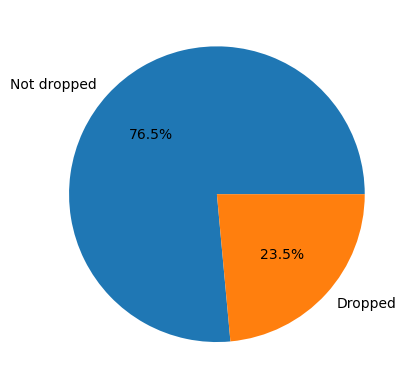

In [11]:
plt.pie(
    classes_count,
    labels=["Not dropped","Dropped"],
    autopct="%1.1f%%"
)

Text(0.5, 1.0, 'Dropout distribution by gender')

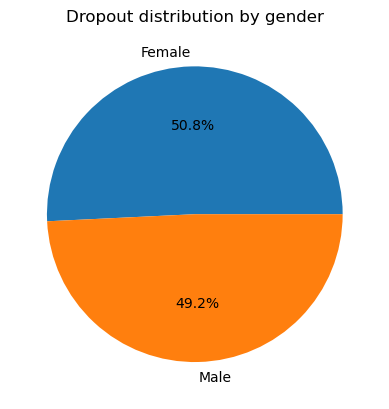

In [12]:
dropouts=df[df["Dropout"]==1]

counts=dropouts["Gender"].value_counts()

plt.pie(counts,
        labels=["Female","Male"],
        autopct="%1.1f%%"
       )

plt.title("Dropout distribution by gender")

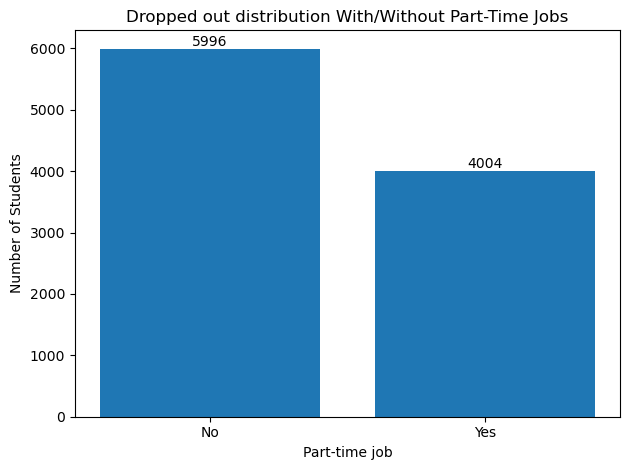

In [13]:
counts=df["Part_Time_Job"].value_counts()

bars = plt.bar(counts.index, counts.values)

plt.bar_label(bars)
plt.xlabel("Part-time job")
plt.ylabel("Number of Students")
plt.title("Dropped out distribution With/Without Part-Time Jobs")

plt.tight_layout()

<Axes: xlabel='Family_Income', ylabel='Count'>

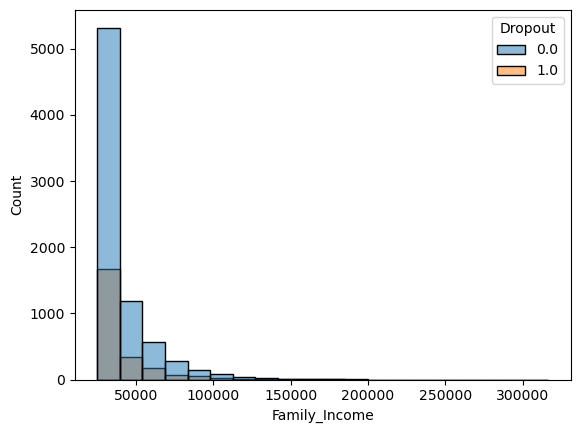

In [14]:
sns.histplot(
    data=df,
    x="Family_Income",
    hue="Dropout",
    bins=20
)

## Feature Encoding

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 10000 non-null  object 
 1   Family_Income          10000 non-null  float64
 2   Internet_Access        10000 non-null  object 
 3   Study_Hours_per_Day    10000 non-null  float64
 4   Attendance_Rate        10000 non-null  float64
 5   Assignment_Delay_Days  10000 non-null  float64
 6   Travel_Time_Minutes    10000 non-null  float64
 7   Part_Time_Job          10000 non-null  object 
 8   Scholarship            10000 non-null  object 
 9   Stress_Index           10000 non-null  float64
 10  CGPA                   10000 non-null  float64
 11  Parental_Education     10000 non-null  object 
 12  Dropout                10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [16]:
ohe=OneHotEncoder(drop="first",handle_unknown="error",sparse_output=False)
ohe_cols=["Gender","Internet_Access","Part_Time_Job"]
encoded=ohe.fit_transform(df[ohe_cols])

In [17]:
ohe.get_feature_names_out(ohe_cols)

array(['Gender_Male', 'Internet_Access_Yes', 'Part_Time_Job_Yes'],
      dtype=object)

In [18]:
encoded_pd=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(ohe_cols),index=df.index)

In [19]:
encoded_pd.head(3)

,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes
0,1.0,1.0,1.0
1,1.0,1.0,0.0
2,1.0,1.0,1.0


In [20]:
df=pd.concat([df.drop(columns=ohe_cols),encoded_pd],axis=1)

In [21]:
df.head()

,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Scholarship,Stress_Index,CGPA,Parental_Education,Dropout,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes
0,25000.000000,3.360000,86.1,2.0,20.4,No,5.500000,0.90,High School,0.0,1.0,1.0,1.0
1,25000.000000,4.300000,68.0,2.0,44.0,No,6.800000,1.19,Bachelor,1.0,1.0,1.0,0.0
2,40183.000000,4.400000,70.9,0.0,48.9,No,5.500000,1.32,Master,0.0,1.0,1.0,1.0
3,38377.247474,4.014592,82.2,2.0,38.6,No,5.507147,1.77,High School,1.0,1.0,1.0,0.0
4,25319.000000,4.190000,75.7,1.0,23.0,No,7.000000,0.87,Bachelor,0.0,0.0,1.0,0.0


In [22]:
df["Parental_Education"].unique()

array(['High School', 'Bachelor', 'Master', 'PhD'], dtype=object)

In [23]:
oe=OrdinalEncoder()

oe = OrdinalEncoder(
    categories=[["High School", "Bachelor", "Master", "PhD"]]
)
df[["Parental_Education"]]=oe.fit_transform(df[["Parental_Education"]])

In [24]:
le=LabelEncoder()
df["Scholarship"]=le.fit_transform(df["Scholarship"])

In [25]:
df.head()

,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Scholarship,Stress_Index,CGPA,Parental_Education,Dropout,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes
0,25000.000000,3.360000,86.1,2.0,20.4,0,5.500000,0.90,0.0,0.0,1.0,1.0,1.0
1,25000.000000,4.300000,68.0,2.0,44.0,0,6.800000,1.19,1.0,1.0,1.0,1.0,0.0
2,40183.000000,4.400000,70.9,0.0,48.9,0,5.500000,1.32,2.0,0.0,1.0,1.0,1.0
3,38377.247474,4.014592,82.2,2.0,38.6,0,5.507147,1.77,0.0,1.0,1.0,1.0,0.0
4,25319.000000,4.190000,75.7,1.0,23.0,0,7.000000,0.87,1.0,0.0,0.0,1.0,0.0


## Correlation HeatMap

In [26]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

<Axes: >

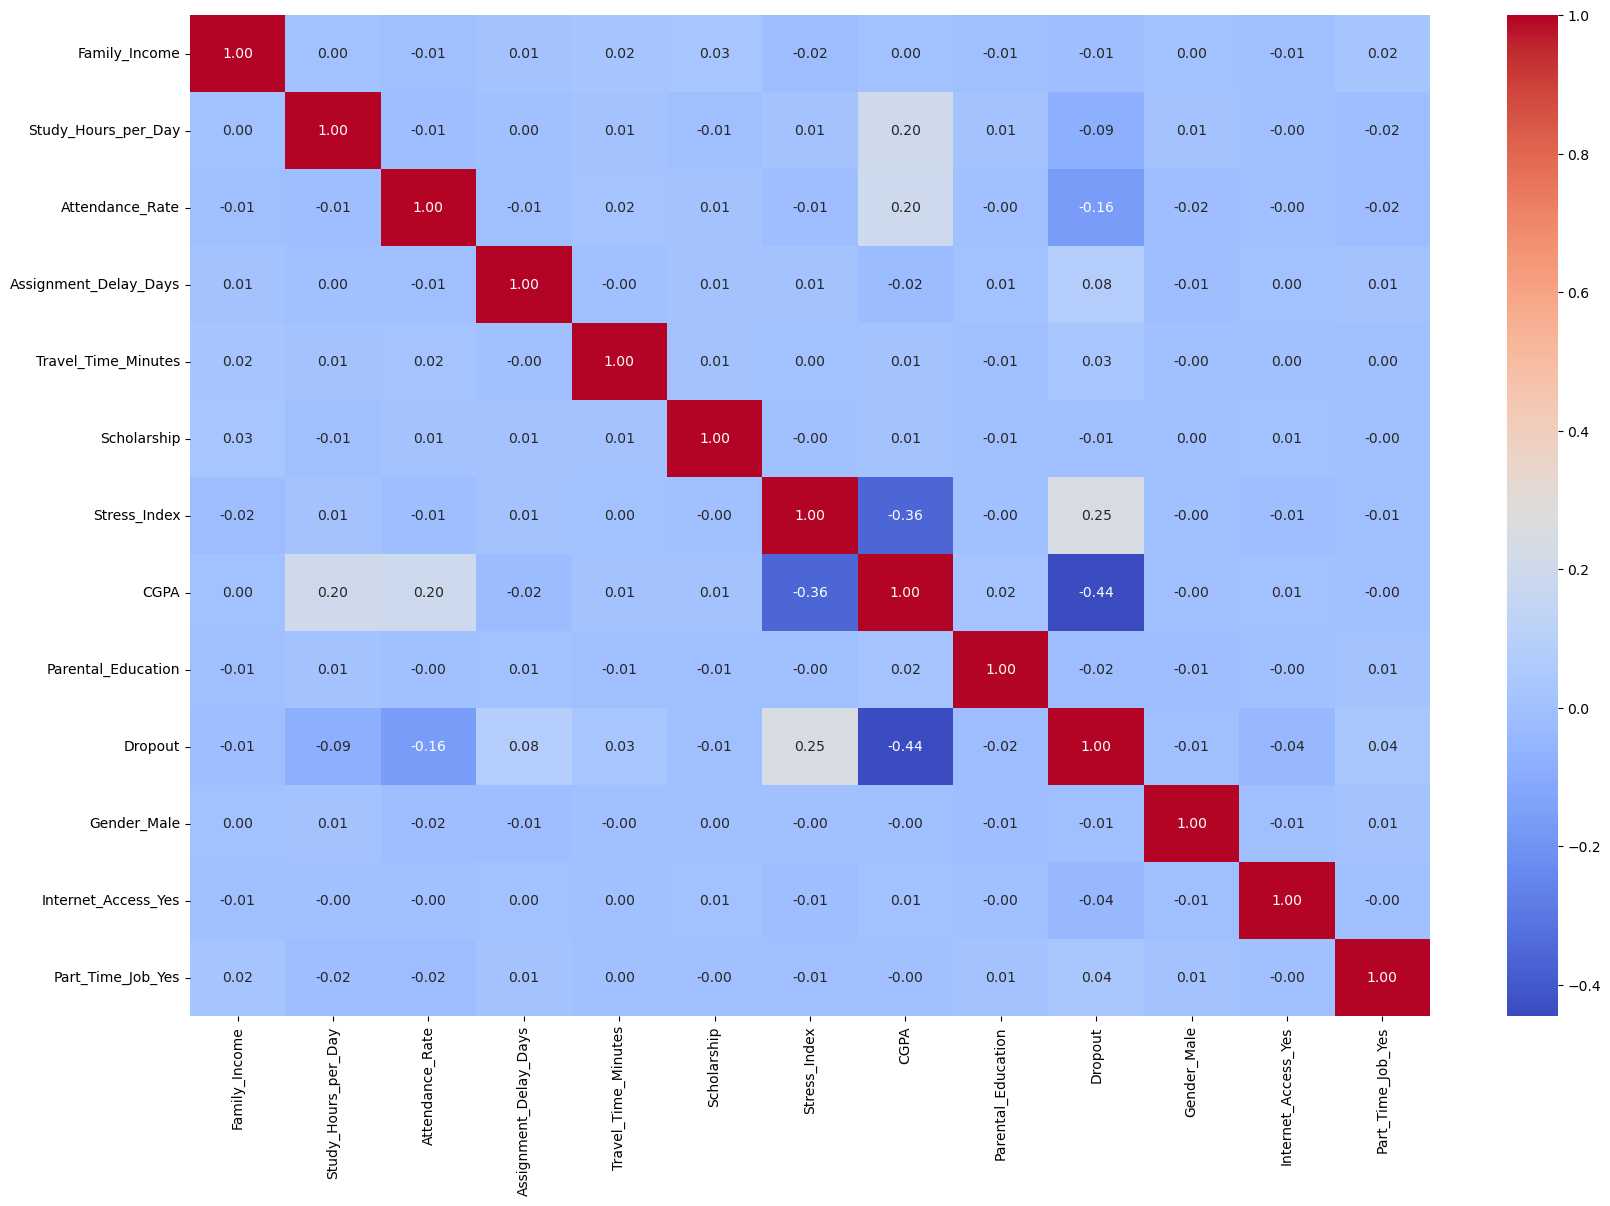

In [27]:
plt.figure(figsize=(20,13))

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

## Train_test_split + scaling

In [28]:
X=df.drop(["Dropout"],axis=1)
y=df["Dropout"]

In [29]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [30]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [31]:
X_pd=pd.DataFrame(X_train_scaled,columns=X.columns)

In [32]:
X_pd.head()

,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Scholarship,Stress_Index,CGPA,Parental_Education,Gender_Male,Internet_Access_Yes,Part_Time_Job_Yes
0,-0.411314,0.563508,-1.175868,0.902618,-1.889146,1.372182,2.415150,-1.387893,1.208518,-0.998751,0.37298,1.224745
1,1.652606,-0.440235,1.271377,-1.331355,0.979204,1.372182,1.895176,-1.257381,-1.186366,-0.998751,0.37298,-0.816497
2,0.767441,-1.941897,-1.395024,1.647276,-0.024300,-0.728766,-0.473596,-0.744657,-1.186366,-0.998751,0.37298,-0.816497
3,-0.338878,-0.290069,0.540856,-0.586697,1.113004,1.372182,0.624127,0.103668,1.208518,1.001251,0.37298,-0.816497
4,-0.665517,0.413341,-2.089019,0.902618,-0.283539,-0.728766,0.450803,-1.798072,-1.186366,-0.998751,0.37298,1.224745


## Train and evaluate Model

#### For this data recall score matters the most because we dont want that a student who dropped out but the model predicted didnt drop out on the other hand we can afford that the model predicted drop out but actually the student didnt drop out

#### In case of confusion matrix , left side bottom value must be as low possible

## 1) Logistic Regression

In [62]:
log_model=LogisticRegression(
    class_weight='balanced',random_state=42,max_iter=100,C=0.01,penalty="l1",solver="liblinear"
)

log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  44.32234432234432 %
Accuracy :  71.8 %
f1 score :  56.27906976744186 %
Recall score :  77.07006369426752 %
confusion matrix :  [[1073  456]
 [ 108  363]]


## 2) Naive Bayes

In [34]:
gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled,y_train)

y_pred=gnb_model.predict(X_test_scaled)

print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  60.94986807387863 %
Accuracy :  80.60000000000001 %
f1 score :  54.352941176470594 %
Recall score :  49.044585987261144 %
confusion matrix :  [[1381  148]
 [ 240  231]]


## 3) KNN

In [35]:
knn_class=KNeighborsClassifier(    
    n_neighbors=3
)
knn_class.fit(X_train_scaled,y_train)

y_pred=knn_class.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  48.94259818731118 %
Accuracy :  76.1 %
f1 score :  40.399002493765586 %
Recall score :  34.394904458598724 %
confusion matrix :  [[1360  169]
 [ 309  162]]


## 4) Decision Tree classifier

In [36]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train_scaled,y_train)

y_pred=full_tree.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  40.0 %
Accuracy :  71.45 %
f1 score :  41.1946446961895 %
Recall score :  42.462845010615716 %
confusion matrix :  [[1229  300]
 [ 271  200]]


## 5) SVC

In [37]:
svc=SVC(kernel="sigmoid")
svc.fit(X_train_scaled,y_train)

y_pred=svc.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  45.51569506726457 %
Accuracy :  74.45 %
f1 score :  44.274809160305345 %
Recall score :  43.09978768577495 %
confusion matrix :  [[1286  243]
 [ 268  203]]


## 6) Ada boost

In [38]:
abc=AdaBoostClassifier(
    estimator=log_model,
    n_estimators=100,
    random_state=42,

)
abc.fit(X_train_scaled,y_train)

y_pred=abc.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  45.924967658473484 %
Accuracy :  73.3 %
f1 score :  57.073954983922825 %
Recall score :  75.3715498938429 %
confusion matrix :  [[1111  418]
 [ 116  355]]


## 7) GB classifier

In [39]:
gbc=GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=150,
    max_depth=3,
    random_state=42
)

gbc.fit(X_train_scaled,y_train)

y_pred=gbc.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  64.28571428571429 %
Accuracy :  80.25 %
f1 score :  46.404341926729984 %
Recall score :  36.30573248407643 %
confusion matrix :  [[1434   95]
 [ 300  171]]


## 8) XG boost

In [40]:
xgb_class=xgb.XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb_class.fit(X_train_scaled,y_train)

y_pred=xgb_class.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  59.41558441558441 %
Accuracy :  79.35 %
f1 score :  46.98331193838254 %
Recall score :  38.853503184713375 %
confusion matrix :  [[1404  125]
 [ 288  183]]


## 9) Voting

In [86]:
voting_clf=VotingClassifier(
    estimators=[
        ("log",log_model),
        ("log1",log_model),
        ("ada",abc)
    ]
)

voting_clf.fit(X_train_scaled,y_train)

y_pred=voting_clf.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  44.32234432234432 %
Accuracy :  71.8 %
f1 score :  56.27906976744186 %
Recall score :  77.07006369426752 %
confusion matrix :  [[1073  456]
 [ 108  363]]


## 10) Stacking

In [87]:

stack_class=StackingClassifier(
    estimators=[
        ("log",log_model),
        ("log1",gnb_model),
        ("ada",abc)
    ],
    final_estimator=log_model,
    cv=5
)

stack_class.fit(X_train_scaled,y_train)
y_pred=stack_class.predict(X_test_scaled)
print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  45.703125 %
Accuracy :  73.15 %
f1 score :  56.65859564164649 %
Recall score :  74.52229299363057 %
confusion matrix :  [[1112  417]
 [ 120  351]]


## Logistic Regression,Ada Boost,voting , stacking

# Final model : Logistic Regression

In [81]:
final_model=LogisticRegression(
    random_state=42,class_weight="balanced",max_iter=100,C=0.01,penalty="l1",solver="liblinear"
)
final_model.fit(X_train_scaled,y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [82]:
y_pred=final_model.predict(X_test_scaled)

print("Precision : ",precision_score(y_test,y_pred)*100,"%")
print("Accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("f1 score : ",f1_score(y_test,y_pred)*100,"%")
print("Recall score : ",recall_score(y_test,y_pred)*100,"%")
print("confusion matrix : ",confusion_matrix(y_test,y_pred))

Precision :  44.32234432234432 %
Accuracy :  71.8 %
f1 score :  56.27906976744186 %
Recall score :  77.07006369426752 %
confusion matrix :  [[1073  456]
 [ 108  363]]
